<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/MonteCarlo-OffPolicy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MonteCarlo Off-Policy

*Description*: En este notebook se desarrolla la implementación del método de **Monte Carlo Off-Policy**, y se emplea sobre el entorno Frozen Lake de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/20


In [1]:
%%capture
!pip install 'gym[box2d]==0.20.0'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


gc.collect()              # Ejecuta el recolector de basura de Python
if torch.cuda.is_available():
    torch.cuda.empty_cache()   # Limpia la caché de la GPU


SEED = 123

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

Usando dispositivo: cpu


In [4]:
# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

class MonteCarloOffPolicyAgent:

    def __init__(self, env: gym.Env, epsilon: float, use_decay: bool, gamma: float):
        self.env = env
        self.eps = epsilon
        self.use_decay = use_decay
        self.gamma = gamma

        self.n_actions = env.action_space.n
        self.n_states = env.observation_space.n

        # Inicialización de tablas: Q (valores), C (pesos acumulados) y retornos
        self.q_table = np.zeros((self.n_states, self.n_actions))
        self.c_table = np.zeros((self.n_states, self.n_actions))
        self.history_returns = {}

    def get_q_values(self):
        return self.q_table

    def log_return(self, state, action, g_value):
        key = (state, action)
        if key not in self.history_returns:
            self.history_returns[key] = []
        self.history_returns[key].append(g_value)

    def get_return(self, state, action):
        return self.history_returns[(state, action)]

    # --- Gestión de Políticas ---

    # Política uniforme
    def get_action_uniform(self, state):
        return np.random.choice(np.arange(self.n_actions))

    def get_uniform_policy(self, state):
        return np.ones(self.n_actions) / self.n_actions

    # Política epsilon-soft. Se usa para el entrenamiento
    def random_epsilon_greedy_policy(self, state):
        pi_A = np.ones(self.n_actions, dtype=float) * self.eps / self.n_actions
        best_action = np.argmax(self.q_table[state])
        pi_A[best_action] += (1.0 - self.eps)
        return pi_A

    # Política epsilon-greedy a partir de una epsilon-soft
    def epsilon_greedy_policy(self, state):
        pi_A = self.random_epsilon_greedy_policy(state)
        return np.random.choice(np.arange(self.n_actions), p=pi_A)

    # Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
    def pi_star_from_Q(self, env):
        done = False
        pi_star = np.zeros([env.observation_space.n, env.action_space.n])
        state, info = env.reset() # start in top-left, = 0
        actions = ""
        while not done:
            action = np.argmax(self.q_table[state, :])
            actions += f"{action}, "
            pi_star[state,action] = action
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        return pi_star, actions


    def update_knowledge(self, episode_data):
        """
        Actualiza Q y C usando la trayectoria del episodio (retrocediendo en el tiempo).
        Implementa Weighted Importance Sampling.
        """
        g_return = 0.0
        weight = 1.0

        # Iterar el episodio desde el final hacia el principio
        for s, a, r in reversed(episode_data):
            g_return = r + self.gamma * g_return

            # Actualización del acumulador de pesos y la función de valor
            self.c_table[s, a] += weight
            self.q_table[s, a] += (weight / self.c_table[s, a]) * (g_return - self.q_table[s, a])

            # Si la acción tomada no es la que dictaría la política objetivo,
            # el peso de la importancia para el resto de la cadena sería 0.
            if a != np.argmax(self.q_table[s]):
                break

            # Actualizar el peso: W = W * (1 / b(a|s))
            weight *= (1.0 / self.random_epsilon_greedy_policy(s)[a])

        return g_return

In [5]:
def on_policy_all_visit(agente, num_episodes=5000):

    # Número de visitas. Vamoa a realizar la versión incremental.
    #n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    # Para mostrar la evolución en el terminal y algún dato que mostrar
    stats = 0.0
    list_stats = [stats]
    step_display = num_episodes / 10

    longitudes = []

    for t in tqdm(range(num_episodes)):
        state, info = agente.env.reset(seed=SEED)
        done = False
        episode = []
        result_sum = 0.0  # Retorno
        while not done:
            if agente.use_decay:
                agente.eps = min(agente.eps, 1000.0/(t+1))

            action = agente.epsilon_greedy_policy(state)
            new_state, reward, terminated, truncated, info = agente.env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = new_state

        result_sum = agente.update_knowledge(episode)


        # Guardamos datos sobre la evolución. Promedio de recompensas
        stats += result_sum
        longitudes.append(len(episode))
        list_stats.append(stats/(t+1))


        # Para mostrar la evolución.  Comentar si no se quiere mostrar
        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {agente.eps}")

    return longitudes, list_stats

In [6]:
def capture_optimal_behavior(agente, limit_steps=100):
    """
    Graba un episodio completo siguiendo la política óptima del agente
    y devuelve las métricas de rendimiento junto con los frames de video.
    """
    visual_frames = []
    current_state, _ = agente.env.reset(seed=SEED)

    accumulated_reward = 0.0
    steps_count = 0
    is_finished = False

    while not is_finished and steps_count < limit_steps:
        # 1. Capturar el estado visual actual
        img_frame = agente.env.render()
        visual_frames.append(img_frame)

        # 2. Decidir acción basada en la política objetivo (greedy)
        chosen_action = np.argmax(agente.get_q_values()[current_state, :])

        # 3. Ejecutar transición en el entorno
        next_s, reward, terminated, truncated, _ = agente.env.step(chosen_action)

        # 4. Actualizar contadores y estado
        accumulated_reward += reward
        current_state = next_s
        steps_count += 1
        is_finished = terminated or truncated

    # Capturar el último frame tras el fin del episodio
    visual_frames.append(agente.env.render())
    agente.env.close()

    return accumulated_reward, steps_count, visual_frames

In [7]:
def creacion_entorno(env_name, map="4x4", render = "ansi", slippery=False, max_episode_steps=100):
  env = gym.make(env_name, is_slippery=slippery, map_name=map, render_mode=render, max_episode_steps=max_episode_steps)
  env.reset(seed=SEED) # Establece la semilla en el entorno de Gymnasium
  return env

In [8]:
env4x4 = creacion_entorno('FrozenLake-v1', "4x4", "rgb_array")

In [9]:
agent_03_decay = MonteCarloOffPolicyAgent(env4x4, epsilon=0.3, use_decay=True, gamma=0.99)
agent_03_nodecay = MonteCarloOffPolicyAgent(env4x4, epsilon=0.3, use_decay=False, gamma=0.99)
agent_07_decay = MonteCarloOffPolicyAgent(env4x4, epsilon=0.7, use_decay=True, gamma=0.99)
agent_07_nodecay = MonteCarloOffPolicyAgent(env4x4, epsilon=0.7, use_decay=False, gamma=0.99)
agent_1_decay = MonteCarloOffPolicyAgent(env4x4, epsilon=1.0, use_decay=True, gamma=0.99)
agent_1_nodecay = MonteCarloOffPolicyAgent(env4x4, epsilon=1.0, use_decay=False, gamma=0.99)


In [10]:
n_episodes = 50000

list_len, list_stats = on_policy_all_visit(agent_03_decay, n_episodes)

 10%|█         | 5206/50000 [00:08<00:38, 1158.04it/s]

success: 0.10594871062404113, epsilon: 0.19996000799840033


 20%|██        | 10200/50000 [00:11<00:21, 1837.42it/s]

success: 0.43397649540014754, epsilon: 0.0999900009999


 31%|███       | 15332/50000 [00:15<00:23, 1507.17it/s]

...

 81%|████████  | 40369/50000 [00:30<00:05, 1844.77it/s]

success: 0.7895874307705596, epsilon: 0.02499937501562461


 90%|█████████ | 45213/50000 [00:33<00:02, 1806.40it/s]

success: 0.8051204016161005, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:36<00:00, 1387.25it/s]


In [11]:
list_len2, list_stats2 = on_policy_all_visit(agent_03_nodecay, n_episodes)

 10%|█         | 5062/50000 [00:10<01:29, 500.89it/s]

success: 0.0, epsilon: 0.3


 21%|██        | 10320/50000 [00:15<00:23, 1696.00it/s]

success: 0.12981128662777808, epsilon: 0.3


 31%|███       | 15269/50000 [00:17<00:18, 1836.39it/s]

...

 81%|████████  | 40335/50000 [00:32<00:05, 1808.21it/s]

success: 0.48502225164384544, epsilon: 0.3


 90%|█████████ | 45190/50000 [00:36<00:02, 1790.82it/s]

success: 0.4988674935682565, epsilon: 0.3


100%|██████████| 50000/50000 [00:38<00:00, 1290.84it/s]


In [12]:
list_len3, list_stats3 = on_policy_all_visit(agent_07_decay, n_episodes)

 10%|█         | 5201/50000 [00:03<00:36, 1216.83it/s]

success: 0.43080643734032237, epsilon: 0.19996000799840033


 21%|██        | 10306/50000 [00:06<00:22, 1764.89it/s]

success: 0.6218215379744327, epsilon: 0.0999900009999


 31%|███       | 15346/50000 [00:09<00:18, 1875.60it/s]

...

 81%|████████  | 40340/50000 [00:23<00:05, 1810.78it/s]

success: 0.835376355073852, epsilon: 0.02499937501562461


 91%|█████████ | 45283/50000 [00:25<00:02, 1958.96it/s]

success: 0.8459088411049334, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:28<00:00, 1725.44it/s]


In [13]:
list_len4, list_stats4 = on_policy_all_visit(agent_07_nodecay, n_episodes)

 10%|█         | 5103/50000 [00:03<00:39, 1138.35it/s]

success: 0.0549544110169632, epsilon: 0.7


 21%|██        | 10257/50000 [00:07<00:24, 1626.59it/s]

success: 0.060018352080202404, epsilon: 0.7


 31%|███       | 15363/50000 [00:10<00:18, 1849.78it/s]

...

 81%|████████  | 40308/50000 [00:24<00:05, 1843.85it/s]

success: 0.1385485737352734, epsilon: 0.7


 90%|█████████ | 45230/50000 [00:27<00:02, 1896.96it/s]

success: 0.14194014286331572, epsilon: 0.7


100%|██████████| 50000/50000 [00:31<00:00, 1606.61it/s]


In [14]:
list_len5, list_stats5 = on_policy_all_visit(agent_1_decay, n_episodes)

 10%|█         | 5139/50000 [00:03<00:38, 1162.83it/s]

success: 0.2288779842509824, epsilon: 0.19996000799840033


 20%|██        | 10222/50000 [00:06<00:28, 1380.34it/s]

success: 0.5065068794045958, epsilon: 0.0999900009999


 31%|███       | 15372/50000 [00:09<00:18, 1849.45it/s]

...

 81%|████████  | 40303/50000 [00:24<00:05, 1926.31it/s]

success: 0.8064601613786269, epsilon: 0.02499937501562461


 90%|█████████ | 45169/50000 [00:26<00:02, 1934.88it/s]

success: 0.8200977607470524, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:29<00:00, 1714.48it/s]


In [15]:
list_len6, list_stats6 = on_policy_all_visit(agent_1_nodecay, n_episodes)

 11%|█         | 5314/50000 [00:03<00:23, 1932.19it/s]

success: 0.012893176925580601, epsilon: 1.0


 21%|██        | 10318/50000 [00:06<00:21, 1853.23it/s]

success: 0.01349103900964047, epsilon: 1.0


 31%|███       | 15305/50000 [00:08<00:17, 1979.98it/s]

...

 80%|████████  | 40224/50000 [00:22<00:05, 1914.91it/s]

success: 0.01296819260049306, epsilon: 1.0


 90%|█████████ | 45196/50000 [00:25<00:03, 1551.32it/s]

success: 0.012979934177918375, epsilon: 1.0


100%|██████████| 50000/50000 [00:28<00:00, 1733.58it/s]


In [16]:
def draw_multiple_learning_curves(results_dict):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.

    results_dict:
        Diccionario donde:
        clave -> nombre experimento/agente
        valor -> lista con historial de métricas
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    ax.set_title("Comparativa de rendimiento")
    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """
    Calcula un suavizado tipo media deslizante sobre una serie temporal.
    """
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    ax.set_title("Evolución del tamaño de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    ax.set_title("Comparativa de longitudes de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

In [20]:
dict_stats = {'eps=0.3, decay=True': list_stats, 'eps=0.3, decay=False': list_stats2, 'eps=0.7, decay=True': list_stats3, 'eps=0.7, decay=False': list_stats4, 'eps=1.0, decay=True': list_stats5, 'eps=1.0, decay=False': list_stats6}
dict_len = {'eps=0.3, decay=True': list_len, 'eps=0.3, decay=False': list_len2, 'eps=0.7, decay=True': list_len3, 'eps=0.7, decay=False': list_len4, 'eps=1.0, decay=True': list_len5, 'eps=1.0, decay=False': list_len6}

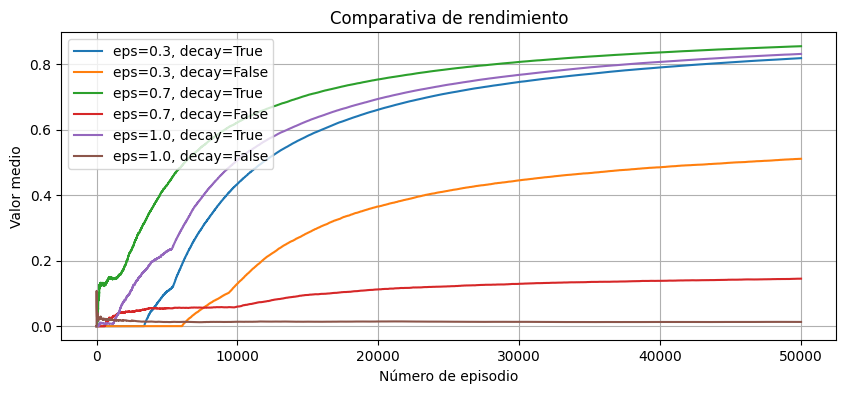

In [18]:
draw_multiple_learning_curves(dict_stats)

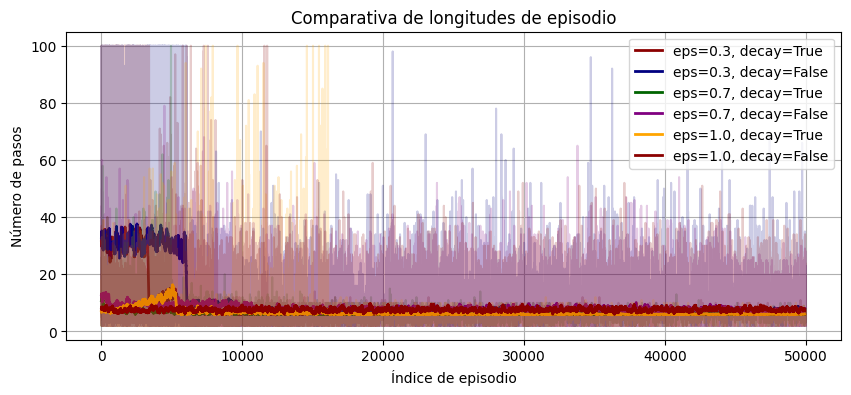

In [21]:
draw_episode_length_comparison(dict_len)

In [23]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt

def map_qtable_to_directions(q_table, grid_size):
    """
    Genera dos matrices a partir de la Q-table:
      1. Valores máximos de Q por estado.
      2. Flechas representando la mejor acción por estado.

    Parámetros:
      - q_table (np.array): Tabla Q (num_states x num_actions)
      - grid_size (int): Tamaño del mapa (map_size x map_size)

    Retorna:
      - q_max_values (np.array): Valores Q máximos por estado
      - q_directions (np.array): Flechas con la mejor acción por estado
    """

    # Valores máximos y acciones óptimas
    q_max_values = q_table.max(axis=1).reshape(grid_size, grid_size)
    best_actions = np.argmax(q_table, axis=1).reshape(grid_size, grid_size)

    # Diccionario de flechas
    arrow_map = {0: "←", 1: "↓", 2: "→", 3: "↑"}

    # Inicializamos la matriz de direcciones como vacía
    q_directions = np.empty(best_actions.size, dtype=str)

    # Valor mínimo positivo para evitar asignar flechas a estados sin información
    min_val = np.finfo(float).eps

    # Recorremos los estados y asignamos flechas solo si el valor Q > eps
    for idx, action in enumerate(best_actions.flatten()):
        if q_max_values.flatten()[idx] > min_val:
            q_directions[idx] = arrow_map[action]

    # Reestructuramos a la forma del mapa
    q_directions = q_directions.reshape(grid_size, grid_size)

    return q_max_values, q_directions

def visualize_q_policy(q_table, environment, grid_size):
    """
    Muestra el último frame del entorno y un heatmap con
    los valores Q aprendidos y la acción óptima por estado.
    """

    # Transformar Q-table en valores máximos y flechas de dirección
    max_vals, best_actions = map_qtable_to_directions(q_table, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Último frame del entorno
    axes[0].imshow(environment.render())
    axes[0].axis("off")
    axes[0].set_title("Último frame")

    # Heatmap de la política
    sns.heatmap(
        max_vals,
        annot=best_actions,
        fmt="",
        ax=axes[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=False,
        yticklabels=False,
        annot_kws={"fontsize": "xx-large"}
    ).set(title="Valores Q aprendidos\nFlechas indican mejor acción")

    # Ajuste de bordes
    for _, spine in axes[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

    plt.show()



def create_gif_from_frames(frame_list, output_path="frozenlake_agent.gif"):
    """
    Genera un GIF animado a partir de una lista de imágenes.

    Parámetros:
      - frame_list (list): Lista de frames capturados del entorno.
      - output_path (str): Nombre del archivo GIF resultante.

    Retorna:
      - str: Ruta del GIF creado.
    """
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """
    Inserta un GIF en una celda de Jupyter Notebook o Colab.

    Parámetros:
      - gif_file_path (str): Ruta del archivo GIF.

    Retorna:
      - HTML: Objeto HTML para mostrar el GIF.
    """
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()

    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

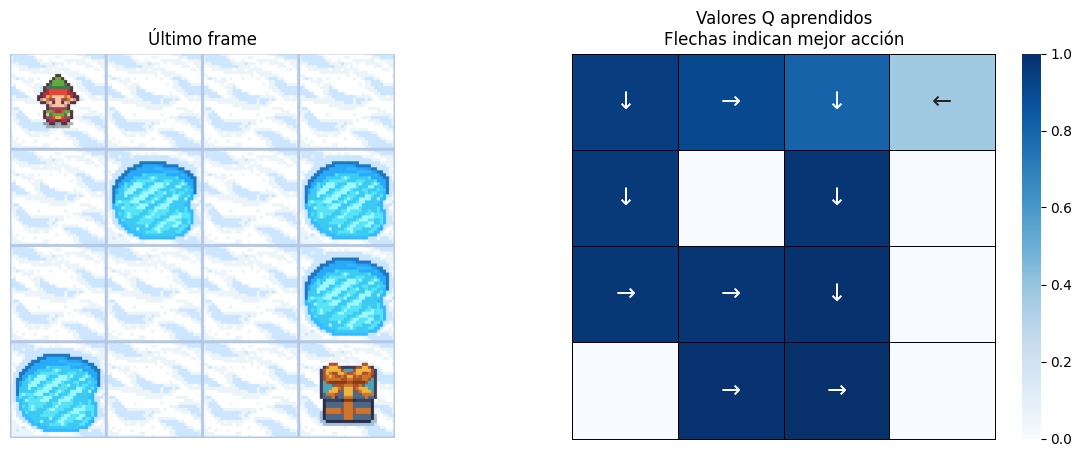

In [24]:
env4x4.reset(seed=SEED)
visualize_q_policy(agent_03_decay.get_q_values(), env4x4, 4)